# Customer Churn Prediction using Logistic Regression

**Name:** Prathmesh Chedge

**Assignment:** AI-ML Assignment 2

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## Load Dataset

In [59]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Understanding

In [60]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Numerical Features:")
print(df.select_dtypes(include=["number"]).columns.tolist())

print("\nCategorical Features:")
print(df.select_dtypes(include=["object", "string"]).columns.tolist())

print("\nTarget Variable:")
print("Churn")

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Target Variable:
Churn


## Data Preprocessing

In [61]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object" or str(df[column].dtype) == "string" or str(df[column].dtype) == "str":
        df[column] = encoder.fit_transform(df[column].astype(str))

In [62]:
print(df.dtypes)

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


## Feature Selection and Data Splitting

In [63]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [65]:
print(X_train.dtypes)

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
dtype: object


## Model Development

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Model Evaluation

In [67]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.815471965933286
Precision: 0.677115987460815
Recall: 0.579088471849866
F1 Score: 0.6242774566473989


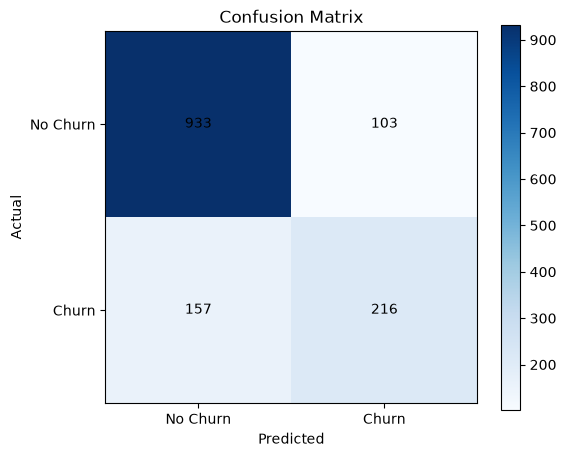

In [68]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.savefig("confusion_matrix.png")
plt.show()

## Observations

1. The Logistic Regression model achieved an accuracy of 81.55%, indicating that it correctly classified most customers.

2. The model achieved a precision of 67.71%, which means that when it predicted a customer would churn, the prediction was often correct.

3. The recall and F1 score indicate that while the model performs well overall, some churning customers are still not identified correctly, leaving room for further improvement.

## Conclusion

This project developed a Logistic Regression model to predict customer churn using the Telco Customer Churn dataset. The dataset was preprocessed by handling missing values, encoding categorical variables, and splitting it into training and testing datasets. The model was evaluated using accuracy, precision, recall, F1 score, and a confusion matrix. The model achieved an accuracy of 81.55%, showing that Logistic Regression is effective for customer churn prediction. Features such as tenure, monthly charges, contract type, and internet services influence customer churn. One limitation of Logistic Regression is that it assumes a linear relationship between the input features and the target variable, which may not capture complex patterns present in the dataset.